<div style="background-color: steelblue; padding: 10px; border-radius: 5px;">
    <p style="margin: 10;"></p>
    <h1 style="text-align: center; margin: 0; font-weight: bold; color: white;">SWOT OMIP : Region Domain</h1>
    <p style="margin: 10;"></p>
</div>


## 📦**Imports** 

In [1]:
%%time

##################################
#Imports

from datetime import datetime
import s3fs
import xarray as xr
import pyinterp
from widetrax import DataPreprocessing as dp
from widetrax import Spectra as sp
import numpy as np
import json
from watermark import watermark
import time
import platform
from shapely.geometry import shape, box

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
#from widetrax import Spectra as sp
import plot_psd1Xglobal1 as pp2X

CPU times: user 1.55 s, sys: 550 ms, total: 2.1 s
Wall time: 6.17 s


## **Load json function**



In [2]:

def read_json_local(folder,file):
        #fs = s3fs.S3FileSystem(key="r3WtYCGWba3FDbT2eKeQ",secret="8OCnb4LX3sPaKkp1aUCzJmfQljmaYsqg2KmQTups", endpoint_url=endpoint_url)
        with open(file, mode='rb') as fileObj:
            data = json.load(fileObj)
        return data

In [3]:
def plot_boxspectrum(region_boxes, cds,selected,region_name,box_legend=0):
    

    colors = [
        "#E6194B",  # red
        "#3CB44B",  # green
        "#FFE119",  # yellow
        "#4363D8",  # blue
        "pink",  # purple
        "k"
        #"#F58231",  # orange
        #
    ]

    #MODEL LOAD

    max_horizontal_gridsize = [0,0,0] #,2.224,2.224,25,7,0]

    fig = plt.figure(figsize=(16, 12))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([cds[0]-2,cds[1]+2,cds[2]-2,cds[3]+2], crs=ccrs.PlateCarree())
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
            color='gray',
        alpha=0.5,
        linestyle='--'
    )

    # Optional: clean up label placement
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.xlines = False
    gl.ylines = False
    ax.set_title(region_name,fontsize=15, fontweight="bold", color="black")
    ax.add_feature(cfeature.LAND,zorder=10, facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE)

    ibox=0
    for ir in region_boxes:
        box=region_boxes[ibox]
        poly=selected[ir]

        # Size of inset (tune this)

        # Box center
        lon_min, lat_min, lon_max, lat_max = poly.bounds
        lon_c = 0.5 * (lon_min + lon_max)
        lat_c = 0.5 * (lat_min + lat_max)

        # Convert lon/lat → figure coordinates
        x_fig, y_fig = ax.transData.transform(
            ccrs.PlateCarree().transform_point(lon_c, lat_c, ccrs.PlateCarree())
            )
        x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))
        w, h = 0.11, 0.11

    
        inset_ax = fig.add_axes([x_fig , y_fig , w, h])
        season="JFM"
        spectrumJFM=[]
        freqJFM=[]
        # Plot spectrum
        models=["GLO12V4","GLO36V1","NOC12","NOC025","GEOMAR","SWOT"] #["GLO12","GLO36","NOC12","NOC025","SWOT"]
        for imod in models :
            folder="GLOBALv2/"
            filename = folder+ imod +"/Global_box_" + str(box) + "_" + season + "_" + imod + ".json"
            data=read_json_local(folder,filename)
            spectrumJFM.append(data["Spectra"])
            freqJFM.append(data["Frequency"])

        season="JAS"
        spectrumJAS=[]
        freqJAS=[]
        # Plot spectrum
        for imod in models :
            folder="GLOBALv2/"
            filename = folder+ imod +"/Global_box_" + str(box) + "_" + season + "_" + imod + ".json"
            data=read_json_local(folder,filename)
            spectrumJAS.append(data["Spectra"])
            freqJAS.append(data["Frequency"])


        if cds[2]>0:
            Ra0=np.squeeze([np.array(spectrumJFM[0])/np.array(spectrumJAS[0])])
            Ra1=np.squeeze([np.array(spectrumJFM[1])/np.array(spectrumJAS[1])])
            Ra2=np.squeeze([np.array(spectrumJFM[2])/np.array(spectrumJAS[2])])
            Ra3=np.squeeze([np.array(spectrumJFM[3])/np.array(spectrumJAS[3])])
            aRa4=np.squeeze([np.array(spectrumJFM[4])/np.array(spectrumJAS[4])])
            Ra5=np.squeeze([np.array(spectrumJFM[5])/np.array(spectrumJAS[5])])
        else:
            Ra0=np.squeeze([np.array(spectrumJAS[0])/np.array(spectrumJFM[0])])
            Ra1=np.squeeze([np.array(spectrumJAS[1])/np.array(spectrumJFM[1])])
            Ra2=np.squeeze([np.array(spectrumJAS[2])/np.array(spectrumJFM[2])])
            Ra3=np.squeeze([np.array(spectrumJAS[3])/np.array(spectrumJFM[3])])
            aRa4=np.squeeze([np.array(spectrumJAS[4])/np.array(spectrumJFM[4])])
            Ra5=np.squeeze([np.array(spectrumJAS[5])/np.array(spectrumJFM[5])])

        adim=len(Ra0)
        Ra4=0*Ra0
        Ra4[0:len(aRa4)]=aRa4
        Ra4[-1]=0
        if ibox==box_legend:
               pp2X.plot_psd(inset_ax, np.array(freqJAS[0]),  psds = [Ra0,Ra1,Ra2,Ra3,Ra4,Ra5] , unit = "m2",psd_labels=models,
                     legend=True,bba_leg=(1,2),xtick_show=True, ytick_show=False,xlabel_upper=False,xlabel_lower=False, 
                     ylabel=False,colors=colors,savefig=True, filename=("globa_" + season + ".png"),plot_transparent=False)

        else:
                pp2X.plot_psd(inset_ax, np.array(freqJAS[0]), psds = [Ra0,Ra1,Ra2,Ra3,Ra4,Ra5], unit = "m2",psd_labels=models,
                      legend=False,xtick_show=True, ytick_show=False,xlabel_upper=False,xlabel_lower=False, 
                      ylabel=False,colors=colors,savefig=True, filename=("globa_" + season + ".png"),plot_transparent=False)
        #del freq, spectrum
        ibox=ibox+1


        inset_ax.set_ylim([1e-1,1e1])
    ax.set_extent([cds[0]-2,cds[1]+2,cds[2]-2,cds[3]+2], crs=ccrs.PlateCarree())
    ax.legend(models)

    return 

In [4]:
def load_spectrum(folder,region_boxes,models):
    box=0
    psdsW=np.zeros((len(region_boxes),5))
    psdsS=np.zeros((len(region_boxes),5))

    # Wavelength to interpole since every boxes has a particular frequency
    Wl=np.array([500,400,300,250,200,150,125,100,90,85,80,75,70,66,62,58,50,48,46,44,42,40,38,36])

    FbS=np.zeros((len(Wl),len(models))) #Mean spectrum over the region in summer
    FbW=np.zeros((len(Wl),len(models))) #Mean spectrum over the region in winter

    km=0
    for imod in models:
        ki=0
        for i in (region_boxes):

            if (i!=14) and (i!=15):
                season="JFM"
                spectrumJFM=[]
                freqJFM=[]
                # Plot spectrum JFM
                filename = folder+ imod +"/Global_box_" + str(i) + "_" + season + "_" + imod + ".json"
                data=read_json_local(folder,filename)
                spectrumJFM.append(data["Spectra"])
                freqJFM.append(data["Frequency"])
                FbW[:,km]=FbW[:,km]+np.interp(1/Wl,np.array(data["Frequency"]), np.array(data["Spectra"]))

                season="JAS"
                spectrumJAS=[]
                freqJAS=[]
                # Plot spectrum JAS
                filename = folder+ imod +"/Global_box_" + str(i) + "_" + season + "_" + imod + ".json"
                data=read_json_local(folder,filename)
                spectrumJAS.append(data["Spectra"])
                freqJAS.append(data["Frequency"])
            
                FbS[:,km]=FbS[:,km]+np.interp(1/Wl,np.array(data["Frequency"]), np.array(data["Spectra"]))
                ki=ki+1
        km=km+1

    FbS=FbS/len(region_boxes)
    FbW=FbW/len(region_boxes)
    return FbS, FbW


In [5]:
from shapely.geometry import shape, box

def position_boxes(regcoord):
    # Reading boxes position over the entire global ocean
    roi = {
        "lon_min": -180,
        "lon_max": 180,
        "lat_min": -90,
        "lat_max": 90
    }
    pos_reg=[-180, -90, 180, 90]

    with open("mostly_ocean_boxes_filtered.geojson") as f:
        data = json.load(f)

    roi_poly = box(roi["lon_min"], roi["lat_min"],
               roi["lon_max"], roi["lat_max"])

    selected = [] 

    for feature in data["features"]:
        poly = shape(feature["geometry"])
        if poly.intersects(roi_poly):
            selected.append(poly)

    region_boxes = []

    for i, feature in enumerate(data["features"]):

        coords = feature["geometry"]["coordinates"][0]

        lats = [c[1] for c in coords]
        lons = [c[0] for c in coords]
        lat_center = sum(lats) / len(lats)
        lon_center = sum(lons) / len(lons)
        if (lat_center >=regcoord[2]) & (lat_center <=regcoord[3]) & (lon_center >=regcoord[0]) & (lon_center <=regcoord[1]) :
            region_boxes.append(i)


    return selected, region_boxes

## **Configuration options**

In [6]:

# Models to process
models=["GLO12V4","GLO36V1","NOC12","NOC025","GEOMAR","SWOT"] #["GLO12","GLO36","NOC12","NOC025","SWOT"]
folder="GLOBALv2/"

## **Load spectrum**

In [7]:
# Defining region: AGULHAS CURRENT
regcoordA=[0,50, -50, -20] # Domain lon_min,lon_max, lat_min, lat_max
selected, region_boxesA=position_boxes(regcoordA) # Index boxes for global ocean, and the region
FbS_A, FbW_A=load_spectrum(folder,region_boxesA,models) # FbS =JAS; FbW=JFM

In [8]:
region_boxesA

[75, 76, 77, 78, 79, 107, 108, 109, 110, 133]

## **Plotting spectrum mean**

/opt/anaconda3/envs/s3env/lib/python3.14/site-packages/widetrax/Spectra.py:239: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))


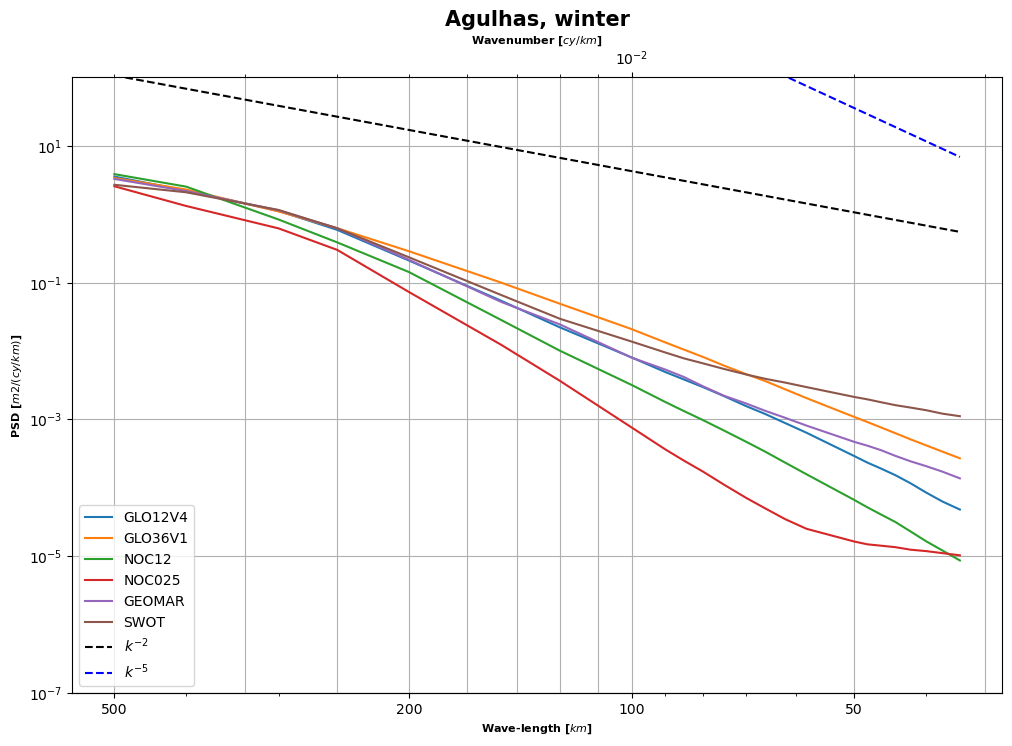

In [9]:
#WINTER MONTH
#NOT MODIFY
Wl=np.array([500,400,300,250,200,150,125,100,90,85,80,75,70,66,62,58,50,48,46,44,42,40,38,36])

# WINTER
from widetrax import Spectra as sp
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
sp.plot_psd(ax, 1/Wl, [FbS_A[:,0],FbS_A[:,1],FbS_A[:,2],FbS_A[:,3],FbS_A[:,4],FbS_A[:,5]], unit = "m2",psd_labels=models,title="Agulhas, winter",savefig=False,plot_transparent=False)


/opt/anaconda3/envs/s3env/lib/python3.14/site-packages/widetrax/Spectra.py:239: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))


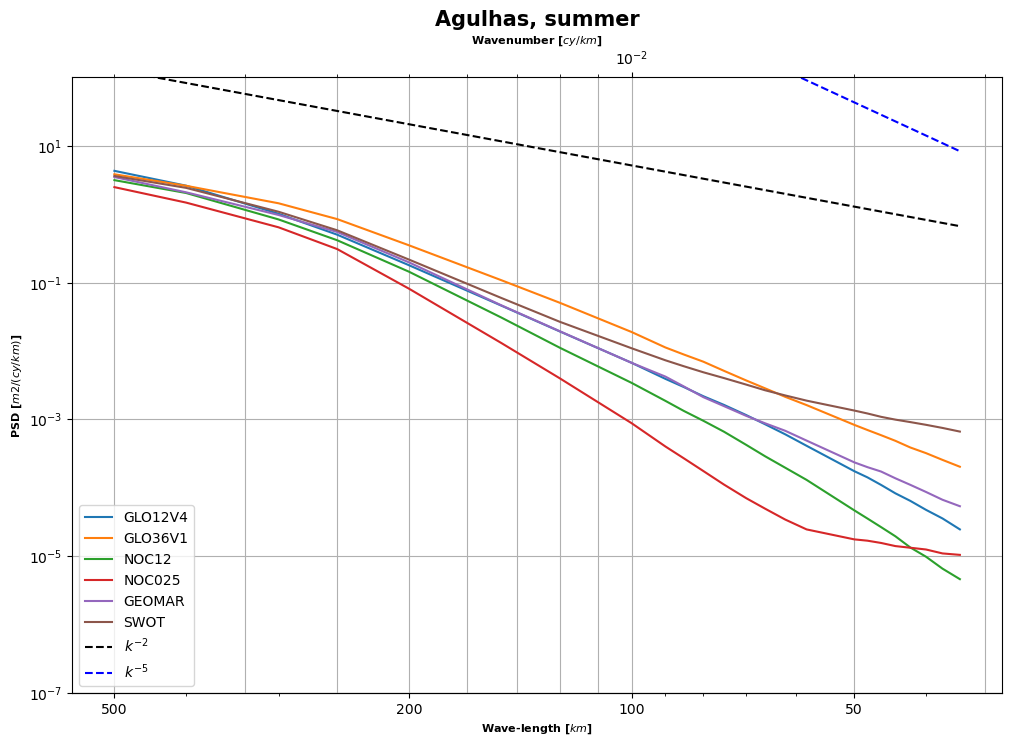

In [11]:
# SUMMER
from widetrax import Spectra as sp

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
sp.plot_psd(ax, 1/Wl, [FbW_A[:,0],FbW_A[:,1],FbW_A[:,2],FbW_A[:,3],FbW_A[:,4],FbW_A[:,5]], unit = "m2",psd_labels=models,title="Agulhas, summer",savefig=False,plot_transparent=False)


## Ratio winter/summer

(0.1, 10.0)

/opt/anaconda3/envs/s3env/lib/python3.14/site-packages/widetrax/Spectra.py:239: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))


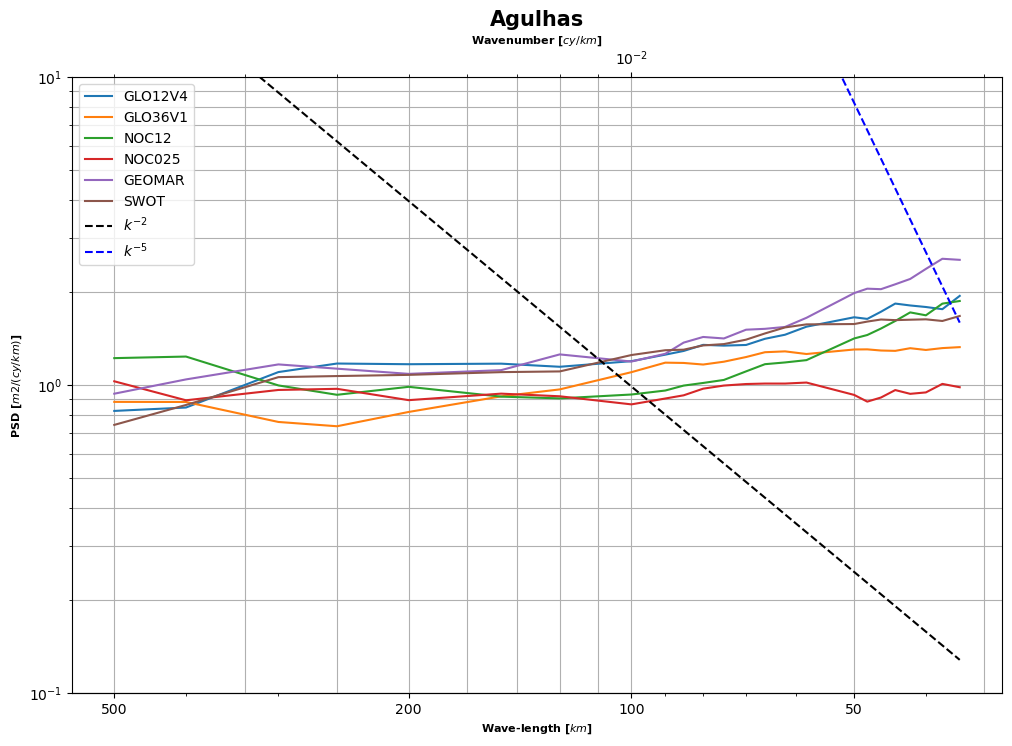

In [90]:
from widetrax import Spectra as sp

Ra_A=FbS_A/FbW_A

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
sp.plot_psd(ax, 1/Wl, [Ra_A[:,0],Ra_A[:,1],Ra_A[:,2],Ra_A[:,3],Ra_A[:,4],Ra_A[:,5]], unit = "m2",psd_labels=models,title="Agulhas",savefig=False,plot_transparent=False)
ax.set_ylim([1e-1,1e1])

# RATIO MODELS/SWOT
## Winter Ratio

(0.1, 10.0)

/opt/anaconda3/envs/s3env/lib/python3.14/site-packages/widetrax/Spectra.py:239: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))


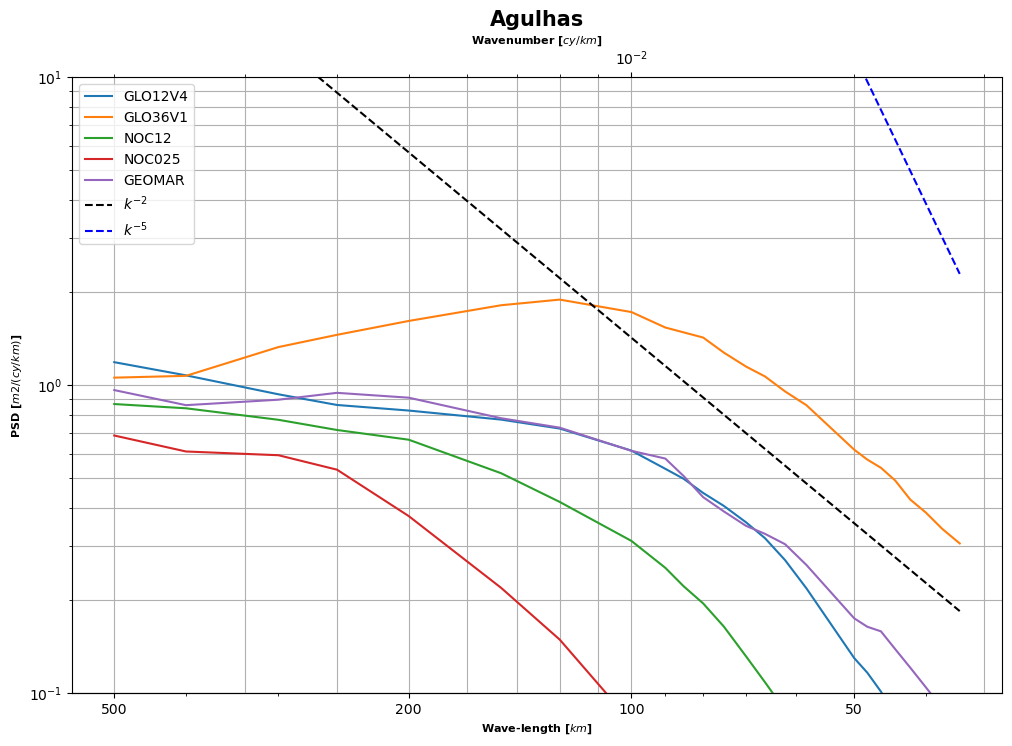

In [27]:
from widetrax import Spectra as sp

Ra_A=FbW_A[:,:5]/np.tile(FbW_A[:,5],(5,1)).T

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
sp.plot_psd(ax, 1/Wl, [Ra_A[:,0],Ra_A[:,1],Ra_A[:,2],Ra_A[:,3],Ra_A[:,4]], unit = "m2",psd_labels=models[:5],title="Agulhas",savefig=False,plot_transparent=False)
ax.set_ylim([1e-1,1e1])

## Summer Ratio

(0.1, 10.0)

/opt/anaconda3/envs/s3env/lib/python3.14/site-packages/widetrax/Spectra.py:239: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))


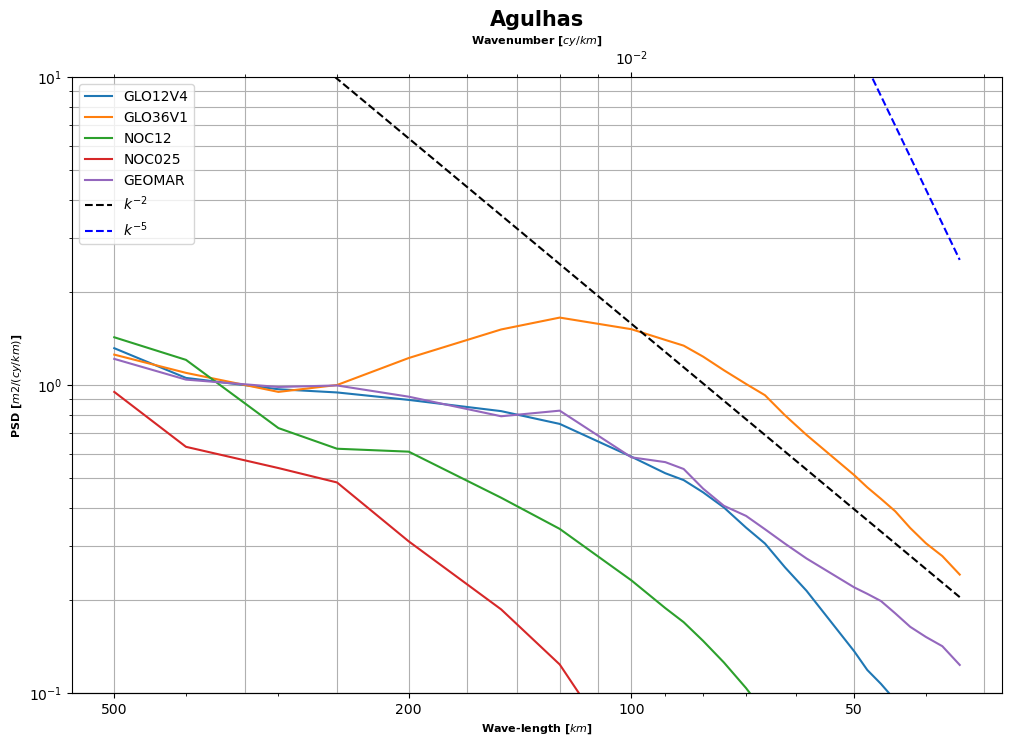

In [26]:
from widetrax import Spectra as sp

Ra_A=FbS_A[:,:5]/np.tile(FbS_A[:,5],(5,1)).T

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
sp.plot_psd(ax, 1/Wl, [Ra_A[:,0],Ra_A[:,1],Ra_A[:,2],Ra_A[:,3],Ra_A[:,4]], unit = "m2",psd_labels=models[:5],title="Agulhas",savefig=False,plot_transparent=False)
ax.set_ylim([1e-1,1e1])

## PLOT SPECTRUM  BOXES

* Here is plotting the ratio winter/summer for every boxes (not averaged)
* Figures are not the best. It's only for test

/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1Xglobal1.py:100: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1Xglobal1.py:100: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1Xglobal1.py:100: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1Xglobal1.py:100: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1Xglobal1.py:100: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lam

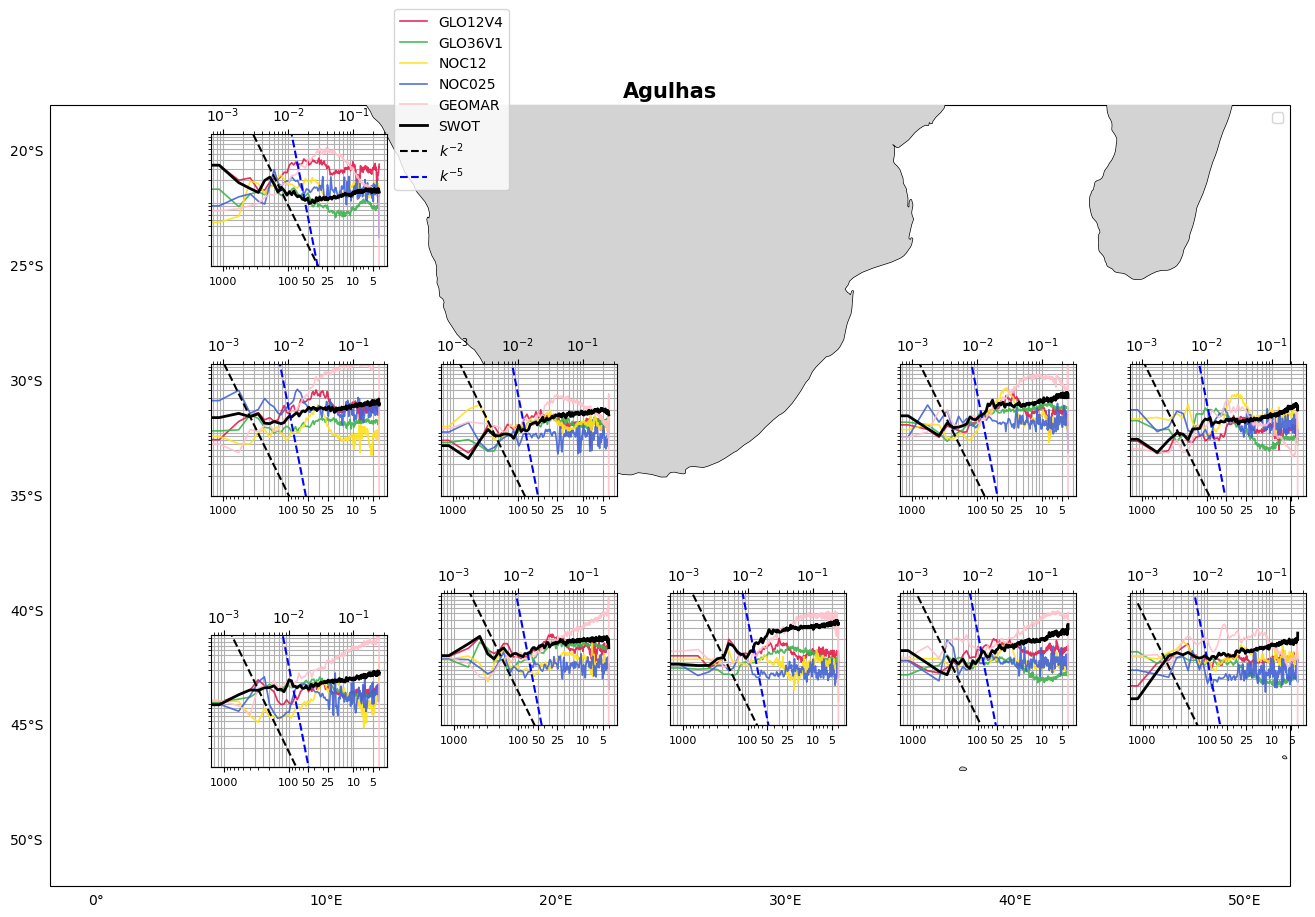

In [31]:
# Colors plot

region_boxes=region_boxesA
cds=regcoordA
fig=plot_boxspectrum(region_boxes, cds,selected,'Agulhas', box_legend=9)



In [ ]:
# DEFINE REGION!
region_boxes=region_boxesK
cds=regcoordK

#---------
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set map extent to Gulf Stream region
ax.set_extent([cds[0]-2,cds[1]+2,cds[2]-2,cds[3]+2], crs=ccrs.PlateCarree())

# Add base map
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Plot selected boxes
for ir in region_boxes:
    poly=selected[ir]
    ax.add_geometries(
        [poly],
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="red",
        linewidth=1.5
    )

ax.set_title("10°×10° Mostly-Ocean Boxes in the Gulf Stream")
plt.show()